# braga2025AIRcloud
This notebook aims to provide a demonstration of how to use the colorcloud library for preprocessing and displaying the results of AIRCloud projected in 2D. For more information, visit [00_behley2019iccv](https://air-ufg.github.io/colorcloud/behley2019iccv.html) documentation.

In [ ]:
#| eval: false
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torch import nn

from matplotlib import pyplot as plt
from collections import defaultdict
from collections import Counter
from pathlib import Path
import numpy as np
import yaml
import os

from colorcloud.behley2019iccv import SemanticKITTIDataset, SphericalProjection, ProjectionTransform, ProjectionVizTransform

## What is AIRCloud?

AIRCloud is a segmented 3D point cloud dataset created by the AIR (Atomic Intelligence Reseach) team at UFG to support research in autonomous driving. It was developed using a Velodyne PUCK VLP-16 LiDAR sensor, which has 16 beams and is more affordable compared to the high-resolution sensors commonly used in international datasets.

The collection resulted in thousands of frames organized into sequences, with annotations in five main classes: car, people, road, vegetation and terrain. The goal is to provide a dataset adapted to the particularities of the Brazilian context, enabling training, testing, and comparison of semantic segmentation models.

For more information about the construction process, methodology, and results, please refer to the [AIRCloud paper](https://sol.sbc.org.br/index.php/semish/article/view/36810).

## Data Loading

To load and use the data, download the dataset (all AIRCloud versions can be found by [clicking here](https://drive.google.com/drive/u/1/folders/15MuazmZj8j1lDZ57SIQuS6F0u9sgK65O)) and move it into a folder named `data` at the root of your workspace.

The next step is to adapt AIRCloud to the format required by the SemanticKITTIDataset class. You can do this using the `88_braga2025format.ipynb` notebook.

After that, simply load the dataset as shown below, making sure to set the `aircloud` flag to **True** since we are not working with the SemanticKITTI dataset.


In [ ]:
#| eval: false
DATA_PATH = '/workspace/data/AIRCloud_V3_F/'

ds = SemanticKITTIDataset(DATA_PATH, aircloud=True)
val_ds = SemanticKITTIDataset(DATA_PATH, split='valid', aircloud=True)
test_ds = SemanticKITTIDataset(DATA_PATH, split='test', aircloud=True)
print(f'train size:\t{len(ds)}\nval size:\t{len(val_ds)}\ntest size:\t{len(test_ds)}')

item = ds[10]
frame = item['frame']
mask = item['mask']
label = item['label']

frame.shape, mask.shape, label.shape

train size:	2374
val size:	750
test size:	0


((19914, 4), (19914,), (19914,))

After being loaded, the labels will be automatically mapped using the `learning_map` from the .yaml file, in order to transform the IDs into indexes and enable training, inference, and other stages.

0: unlabeled & outlier \
1: car \
2: person \
3: road \
4: vegetation \
5: terrain 

## Data Projection

If you want to visualize the projection results, you will need a function to display them. The function below can serve as a good starting point for demonstrating the results."

In [ ]:
#| eval: false
def plot_projections(img, label):
    fig, axs = plt.subplots(6, 1, figsize=(20,10), layout='compressed')
    for i, (ax, title) in enumerate(zip(axs, ['x', 'y', 'z', 'r', 'd', 'label'])):
        if i < 5:
            ax.imshow(img[:,:,i])
        else:
            ax.imshow(label)
        ax.set_title(title)
        ax.axis('off')

The Velodyne LiDAR PUCK 16 has a field of view (FOV) of +/- 15 degrees up and down. For more information about the LiDAR specifications, [click here](https://www.amtechs.co.jp/product/VLP-16-Puck.pdf).

The scaling values were defined by analyzing the entire dataset, seeking the minimum and maximum values for each feature.

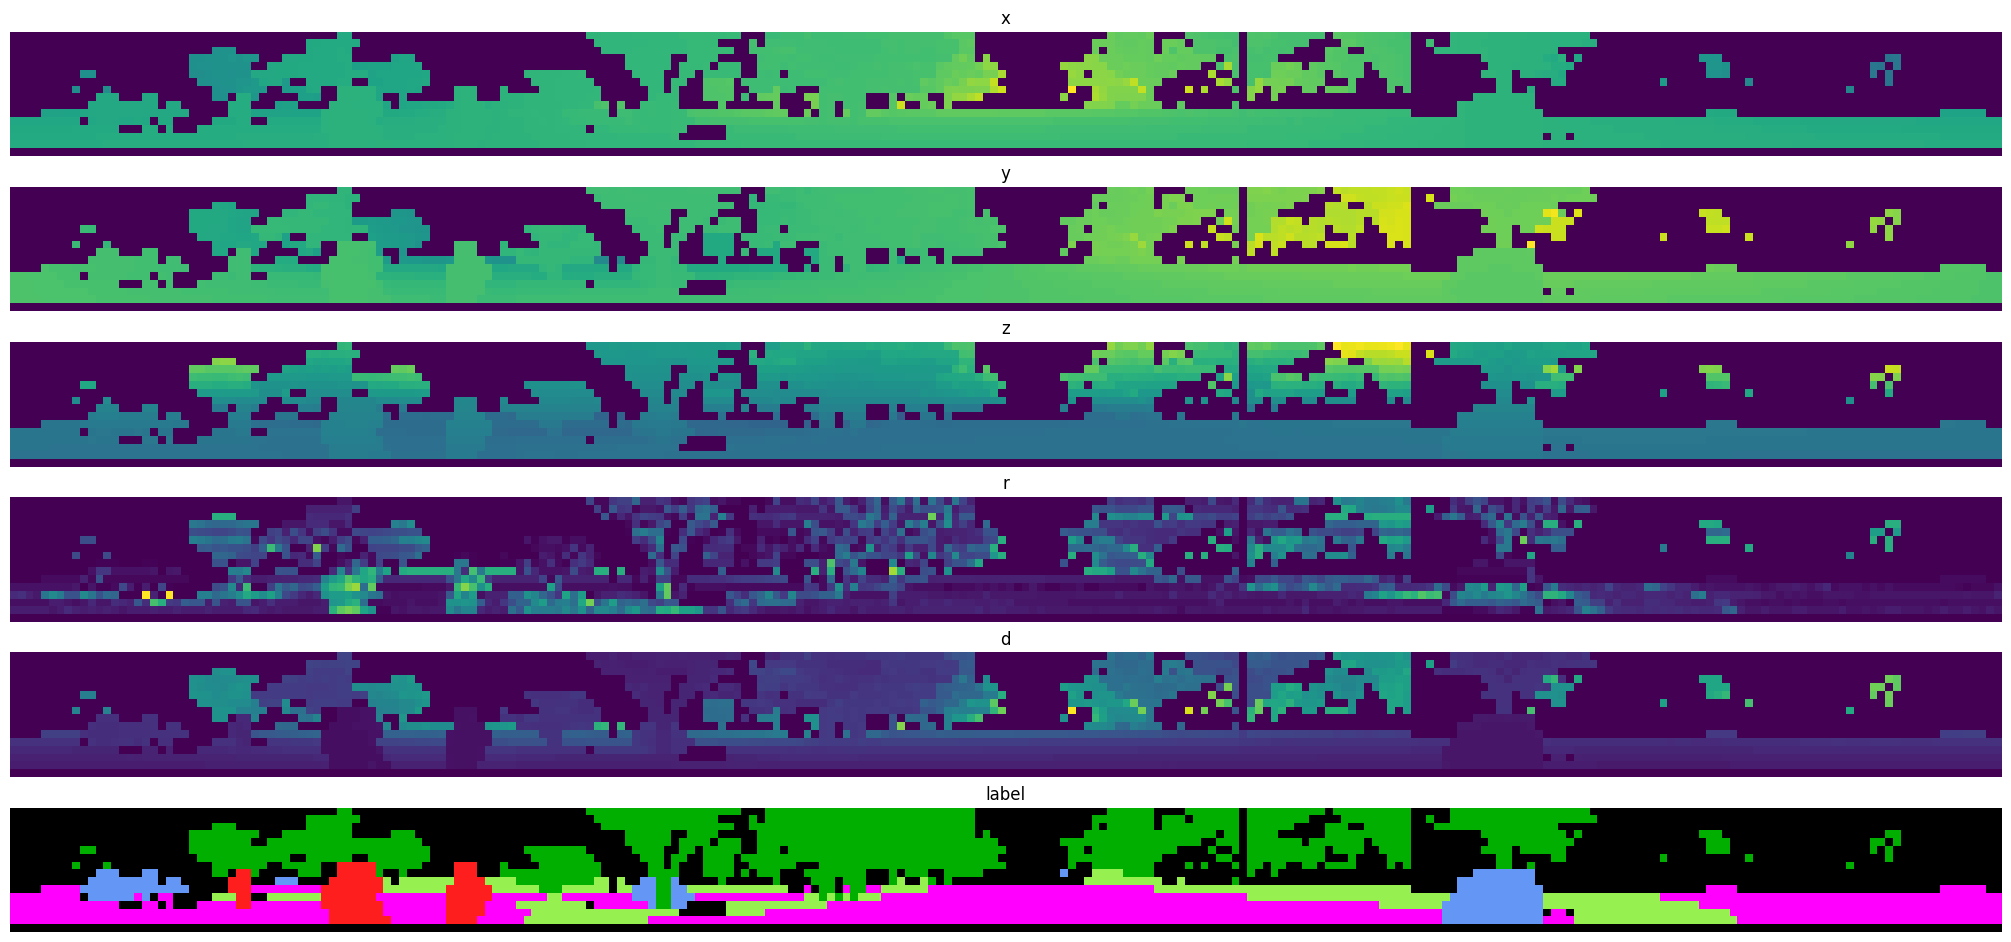

In [ ]:
#| eval: false
proj = SphericalProjection(fov_up_deg=15., fov_down_deg=-15., W=256, H=16)  # these values were taken from [https://github.com/PRBonn/semantic-kitti-api/blob/master/auxiliary/laserscan.py]
scaling_values = {
    "x" : {"min": -150., "max":150.},
    "y" : {"min": -150., "max":150.},
    "z" : {"min": -10., "max":30.},
    "r" : {"min": 0., "max":1.},
    "d" : {"min": 0., "max":130.}
}
tfms = v2.Compose([
    ProjectionTransform(proj),
    ProjectionVizTransform(ds.color_map_rgb_np, ds.learning_map_inv_np, scaling_values),
])
ds.set_transform(tfms)
item = ds[0]
img = item['frame']
label = item['label']

plot_projections(img, label)

## Exploratory Data Analysis

Since in our .yaml file the training split, by default, includes all sequences (07, 08, 09, 10), we will use this same configuration for the subsequent analyses.

In [ ]:
#| eval: false
ds = SemanticKITTIDataset(DATA_PATH, split="train", aircloud=True)
print(f"Number of frames: {len(ds)}")

Number of frames: 2374


Next, we will compute the total number of points for each semantic class in the dataset, resulting in the `total_counts` dictionary.

In [ ]:
#| eval: false
class_map = {
    0: "unlabeled",
    1: "car",
    2: "person",
    3: "road",
    4: "vegetation",
    5: "terrain"
}

all_counts = []
for i in range(len(ds)):
    labels = ds[i]["label"]
    u, c = np.unique(labels, return_counts=True)
    d = dict(zip(u, c))
    all_counts.append({k: d.get(k, 0) for k in class_map})

total_counts = {k: sum(fr[k] for fr in all_counts) for k in class_map}
total_counts

{0: 7005394, 1: 1027910, 2: 255009, 3: 16708079, 4: 14725819, 5: 9486458}

With the dictionary available, we can generate different visualizations to better understand how the data is distributed.

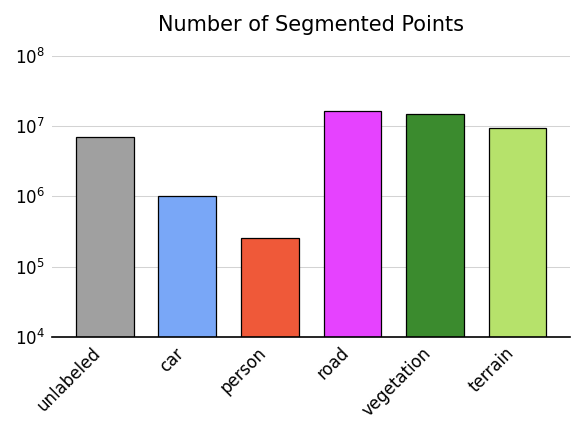

In [ ]:
#| eval: false
labels = list(class_map.values())
values = list(total_counts.values())
bar_colors = ["#A0A0A0", "#79A7F7", "#EF5939", "#E642FF", "#3B8B2E", "#B6E26B"]

plt.figure(figsize=(4, 3), dpi=150)
bars = plt.bar(
    labels,
    values,
    width=0.7,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
)

plt.title("Number of Segmented Points", fontsize=10, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)

plt.yscale("log")
plt.ylim(1e4, 1e8) 

ax = plt.gca()
ax.set_axisbelow(True)
plt.grid(axis="y", color="lightgray", linestyle="-", linewidth=0.5, alpha=1)

plt.tick_params(axis="y", which="minor", length=0)
plt.tick_params(axis="both", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

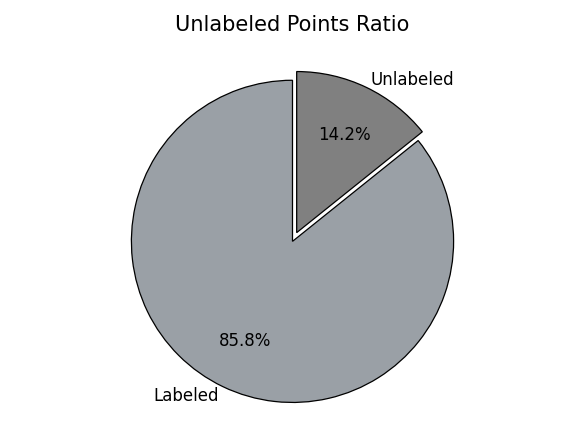

In [ ]:
#| eval: false
unlabeled_count = int(total_counts[0])
others_count = int(sum(v for k, v in total_counts.items() if k != 0))

sizes  = [unlabeled_count, others_count]
labels = ["Unlabeled", "Labeled"]
colors = ["#808080", "#9AA0A6"]  

plt.figure(figsize=(4, 3), dpi=150)

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=[0.03, 0.03],              
    startangle=90,
    counterclock=False,
    autopct="%.1f%%",
    pctdistance=0.68,                  
    labeldistance=1.06,                
    wedgeprops=dict(linewidth=0.6, edgecolor="black"),
    textprops=dict(fontsize=8)
)

plt.axis("equal")
plt.title("Unlabeled Points Ratio", fontsize=10, pad=12)
plt.tight_layout()
plt.show()